**Sam Polyakov and Teagan Turner**

Fall 2025

CS 343: Neural Networks

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from adaline import Adaline

# Set the color style so that Professor Layton can see your plots
plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
# Make the font size larger
plt.show()
plt.rcParams.update({'font.size': 18})

# Turn off scientific notation when printing
np.set_printoptions(suppress=True, precision=3)

# Automatically reload your external source code
%load_ext autoreload
%autoreload 2

# Project 1 | Single-Layer Networks

In this project, you will implement single-layer neural networks that includes the same fundamental components as larger multi-layer networks. You will get familiar with the most common "neural network workflow":
- preprocessing data
- training a neural network
- evaluating test data
- examining performance metrics

We will take advantage of the relative simplicity of single-layer neural networks to analyze and visualize the learned class decision boundaries (*this is more difficult and less intuitive in more complex neural networks that we will study!*).

You will also investigate how the same neural network architecture can be used for both classification and regression with only modest changes.

#### Reminders

- In this class, use `numpy ndarray` (`np.array()`), not Numpy Matrix.
- To help safeguard against data loss when working in a jupyter notebook, make sure the notebook is `Trusted` (Top right corner of notebook when opened in your browser). This will ensure your work autosaves. **I still recommend manually saving at least every few minutes with (Control+S / Cmd+S)**

## Task 1: Implement the ADAptive LInear NEuron (ADALINE) network for binary classification

In Task 1, complete the methods of the `Adaline` class in `adaline.py`. This includes:

- `net_input(self, features)`
- `activation(self, net_in)`
- `loss(self, errors)`
- `accuracy(self, y, y_pred)`
- `gradient(self, errors, features)`

- `predict(self, features)`
- `fit(self, features, y, n_epochs, lr)`

**Important:** Before starting, read through the method descriptions and expected inputs/outputs. It probably would be a good idea to tackle simpler/smaller methods first, then use them in more complex ones. For example, it may be a good idea to work on `net_input` first because it is required to complete `fit`. There is test code below.

Here is a summary of the ADALINE network equations

##### Net input

$\vec{x}_i$ is one of the $N$ data sample vectors from the dataset matrix $A$. That is, `x_i.shape = (M,)`.

$$\text{netIn}_i = \sum_{j=1}^M x_{ij} w_j + b$$

##### Net activation

Identity function:

$$ f(x) = x $$

So:

$$\text{netAct}_i = \text{netIn}_i$$


##### Loss: Sum of squared error

$$L(\vec{w}) = \frac{1}{2} \sum_{i=1}^N \left ( y_i - \text{netAct}_i \right )^2 $$

##### Gradient (bias)

$$\frac{\partial L}{\partial b} = -\sum_{i=1}^N \left ( y_i - \text{netAct}_i \right )$$

##### Gradient (wts)

Below, $x_{ij}$ is the $j^{th}$ feature of the data sample vector $\vec{x}_i$.

$$\frac{\partial L}{\partial w_j} = -\sum_{i=1}^N \left ( y_i - \text{netAct}_i \right ) x_{ij}$$

##### Gradient descent (delta rule)

$$b(t+1) = b(t) - \eta \frac{\partial L}{\partial b}$$
$$w_j(t+1) = w_j(t) - \eta \frac{\partial L}{\partial w_j}$$

above $\eta$ is the learning rate, and $N$ is the training set (number of data samples in training epoch).

### 1a. Test your ADALINE implementation

In [3]:
net = Adaline()

#### Test `accuracy` function

In [4]:
rng = np.random.default_rng(0)
randErrors = np.array([-0.535,  0.222, -0.391,  0.196, -0.29 , -1.953])
randClasses1 = np.where(randErrors >= 0, 1, -1)
randClasses2 = np.roll(randClasses1, 1)
acc1 = net.accuracy(randClasses1, randClasses1)
acc2 = net.accuracy(randClasses1, randClasses2)
print(f'Test 1: Your accuracy is {acc1} and it should be 1.0')
print(f'Test 2: Your accuracy is {acc2:.4f} and it should be 0.3333')

Test 1: Your accuracy is 1.0 and it should be 1.0
Test 2: Your accuracy is 0.3333 and it should be 0.3333


#### Test `predict` function

In [5]:
rng = np.random.default_rng(0)
inputs = rng.standard_normal([10, 4])
net.wts = rng.standard_normal(4)
net.b = rng.standard_normal(1)
y_pred = net.predict(inputs)
print(f'Your predicted classes are {y_pred}.\n            They should be [ 1  1 -1  1  1  1 -1 -1  1  1]')

Your predicted classes are [ 1  1 -1  1  1  1 -1 -1  1  1].
            They should be [ 1  1 -1  1  1  1 -1 -1  1  1]


#### Test `loss` function

In [6]:
rng = np.random.default_rng(2)
net_act = rng.random(len(randErrors))
debugLoss = net.loss(randErrors, net_act)
print(f'Your loss is {debugLoss:.4f} and it should be 5.0434')

Your loss is 5.0434 and it should be 5.0434


#### Test `gradient` function

In [7]:
rng = np.random.default_rng(0)
randFeatures = rng.normal(loc=0, scale=1, size=(15,4))
randErrors1 = rng.normal(loc=0, scale=1, size=(15,))
randBiasGrad, randWtGrad = net.gradient(randErrors1, randFeatures)
print(f'Test 1: Your bias gradient is {randBiasGrad:.3f} and it should be -3.985')
print(f'Test 2: Your wt gradient is {randWtGrad} and it should be [-5.231 -0.2    6.001  6.55 ]')

Test 1: Your bias gradient is -3.985 and it should be -3.985
Test 2: Your wt gradient is [-5.231 -0.2    6.001  6.55 ] and it should be [-5.231 -0.2    6.001  6.55 ]


#### Test `fit` function

In [8]:
rng = np.random.default_rng(0)
net = Adaline()
inputs = rng.standard_normal([9, 6])
y = np.sign(rng.standard_normal(9))
loss, acc = net.fit(inputs, y, r_seed=0)
print(f'Your end-of-training loss / accuracy are\n{loss[-1]:.4f} / {acc[-1]:.4f}.\nThey should be\n0.5477 / 1.0000.')
print(f'Your wts after training are:\n{net.get_wts()}\nand should be\n[-0.288  1.363 -0.204 -0.085 -0.246 -0.498]')

Your end-of-training loss / accuracy are
0.5477 / 1.0000.
They should be
0.5477 / 1.0000.
Your wts after training are:
[-0.288  1.363 -0.204 -0.085 -0.246 -0.498]
and should be
[-0.288  1.363 -0.204 -0.085 -0.246 -0.498]


### 1b. Load in and preprocess old faithful data

In this task, you will be working with the old faithful dataset. Here is a description of the dataset:

    Waiting time between eruptions and the duration of the eruption for the Old Faithful geyser in Yellowstone National Park, Wyoming, USA.

    Variables:
    ----------
    sample     numeric      Measurement number
    eruptions  numeric      Eruption time in mins
    waiting    numeric      Waiting time to next eruption
    severe     categorical  Whether the eruption was "severe"
                            (+1: severe, -1 not severe)

Write code to do the following in the below cell.

1. Load in `old_faithful.csv`, represent the data using a ndarray. Select the `eruptions` and `waiting` variables for your features.  Shape = [Num samps, Num features] = [272, 2].
2. Assign the output classes (**severe**) to a separate 1D ndarray vector. Shape=(272,)
3. Preprocess the data by performing min-max normalization across features (i.e. the CS251/2 way "per-variable"/"separately").
4. Use matplotlib to create a scatter plot of the normalized data, color-coding data points according to their class
5. I suggest using pandas, but you're welcome to do this however you like.

**Make sure that executing the below cell results in an inline scatter plot, color-coded by class.**

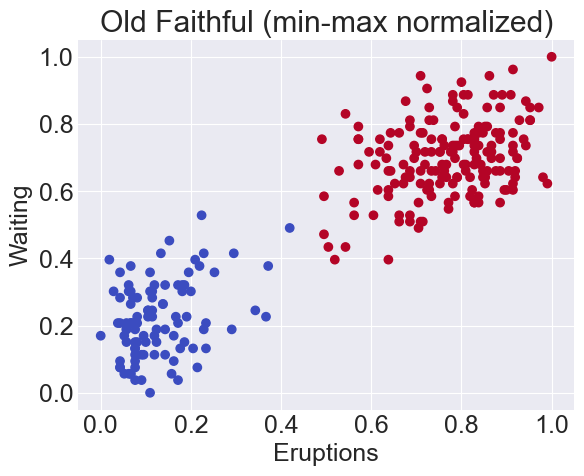

In [9]:
# YOUR CODE HERE
df = pd.read_csv('old_faithful.csv')
X = df[['eruptions','waiting']].to_numpy()
y = df['severe'].to_numpy()

X_min = X.min(axis=0)
X_max = X.max(axis=0)

X_norm = (X - X_min) / (X_max - X_min)

plt.scatter(X_norm[:, 0], X_norm[:, 1], c=y, cmap='coolwarm')
plt.xlabel("Eruptions")
plt.ylabel("Waiting")
plt.title("Old Faithful (min-max normalized)")
plt.show()


### 1c. Train ADALINE on normalized Old Faithful data using default hyperparameters (i.e. learning rate, epochs)

Print out the final loss and accuracy, then use the provided function to plot your training results inline in the below cell.

By the final epoch, training loss should reach ~11.36 and accuracy ~100%.

In [10]:
# YOUR CODE HERE
net = Adaline()
loss, acc = net.fit(X_norm, y)
print(f"Loss: {loss[-1]} \nAccuracy: {acc[-1]}")

Loss: 11.355890974612585 
Accuracy: 1.0


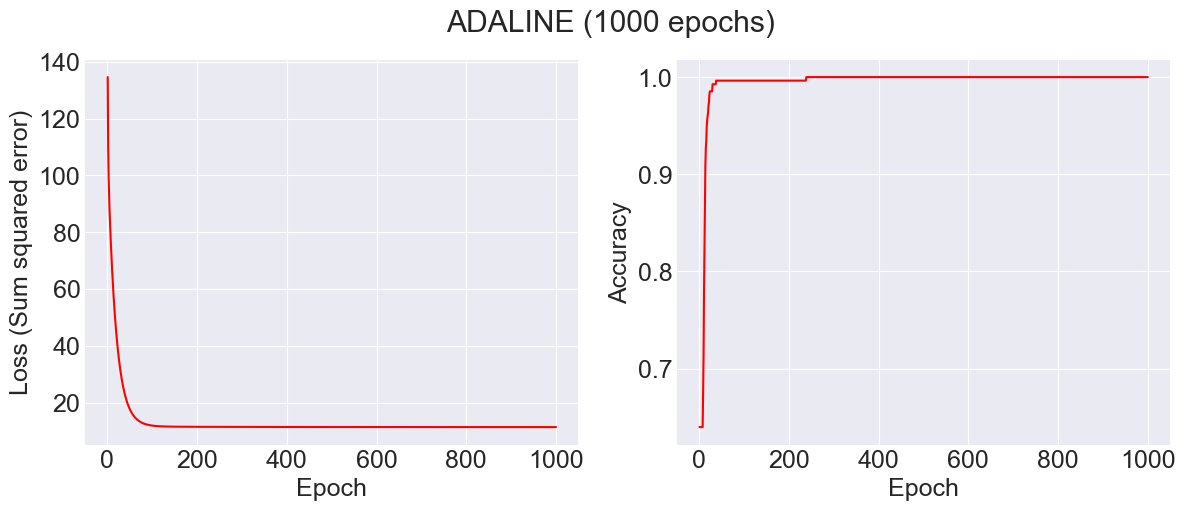

In [11]:
def plot_adaline_train(net, loss_list, acc_list, plotMarkers=False, title='ADALINE'):
    '''Helper plotting function provided for you.'''
    n_epochs = len(loss_list)

    x = np.arange(1, n_epochs+1)

    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
    fig.suptitle(f'{title} ({n_epochs} epochs)')

    curveStr = '-r'
    if plotMarkers:
        curveStr += 'o'

    ax1.plot(x, loss_list, curveStr)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss (Sum squared error)')
    ax2.plot(x, acc_list, curveStr)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')

    plt.show()

# YOUR CODE HERE
plot_adaline_train(net, loss, acc)

#### Questions

**Question 1.** Based on your loss and accuracy curves, does it look like your network learned to classify the old faithful data? Why or why not?

**Answer 1:**

Yes, the loss drops to almost nothing and the accuracy jumps to ~1. They both also flatten, which together shows that ADALINE successfully separates the Old Faithful data.

## Task 2: Feature scaling and hyperparameters


### 2a. Feature scaling

Copy your code from Task 1 to import the Old Faithful data, but this time don't normalize before training.

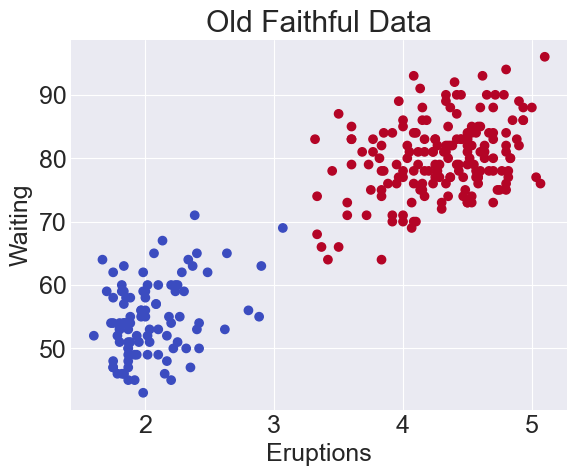

In [14]:
# YOUR CODE HERE
df = pd.read_csv('old_faithful.csv')
X = df[['eruptions','waiting']].to_numpy()
y = df['severe'].to_numpy()

X_min = X.min(axis=0)
X_max = X.max(axis=0)

# X_norm = (X - X_min) / (X_max - X_min)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm')
plt.xlabel("Eruptions")
plt.ylabel("Waiting")
plt.title("Old Faithful Data")
plt.show()


In [17]:
net = Adaline()
loss, acc = net.fit(X, y)
print(f"Loss: {loss[-1]} \nAccuracy: {acc[-1]}")

Loss: nan 
Accuracy: 0.3602941176470588


/Users/teaganturner/Desktop/CS/CS343/Project 0/Neural-Networks/Project 1/adaline.py:118: RuntimeWarning: overflow encountered in square
  return 0.5 * np.sum(diff ** 2)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/Users/teaganturner/Desktop/CS/CS343/Project 0/Neural-Networks/Project 1/adaline.py:139: RuntimeWarning: overflow encountered in matmul
  grad_wts = -features.T @ errors
/Users/teaganturner/Desktop/CS/CS343/Project 0/Neural-Networks/Project 1/adaline.py:195: RuntimeWarning: invalid value encountered in subtract
  self.wts -= lr * grad_w
/Users/teaganturner/Desktop/CS/CS343/Project 0/Neural-Networks/Project 1/adaline.py:196: RuntimeWarning: invalid value encountered in scalar subtract
  self.b   -= lr * grad_b


#### Questions

**Question 2.** What happens to the loss when we don't normalize the features before training? Why?

**Answer 2:**

Without normalization, features on larger scales dominate the gradients, causing unstable updates and numerical overflow, so the loss diverges to NaN. Normalizing puts features on the same scale, keeping training stable.

### 2b. Test how individually standardizing your features affects the rate at which loss decreases over epochs

1. Write code in the cell below to train the network on standardized features. Recall that standardizing a variable means applying the transformation $\frac{x - \mu}{\sigma}$. The mean and standard deviation should be computed over the entire dataset and separately per feature.
2. Plot the loss and accuracy.

**The cell should generate an inline pair of plots when executed**.

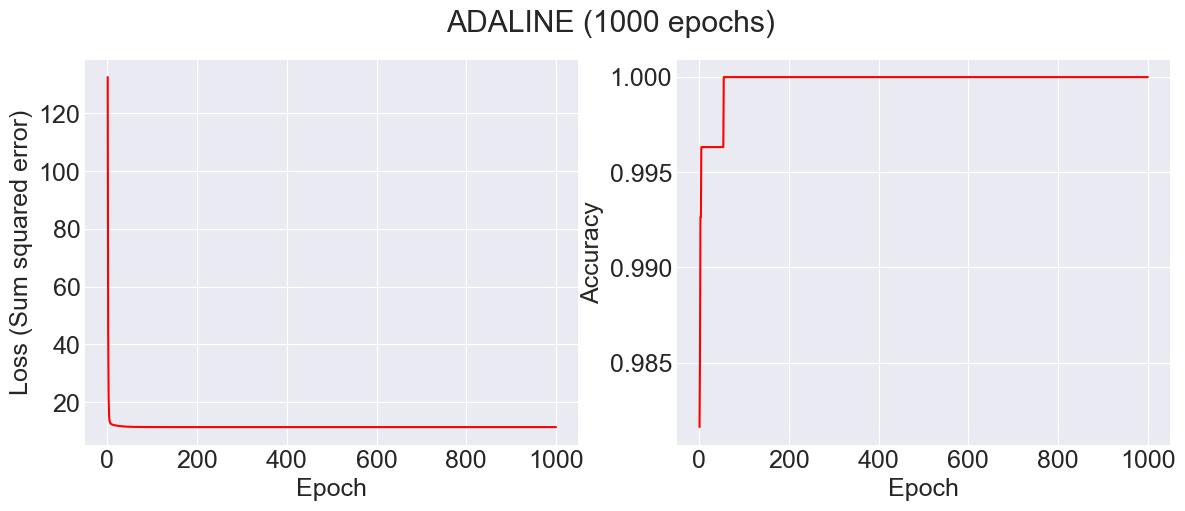

In [18]:
X_stndrd = (X - X.mean(axis=0)) / X.std(axis=0)

net = Adaline()
loss, acc = net.fit(X_stndrd, y)

# YOUR CODE HERE
plot_adaline_train(net, loss, acc)


#### Questions

**Question 3.** Explain the similarities/differences in loss and accuracy curves between these plots and those that you made in Task 1.

**Answer 3:**

These curves are much steeper and move in 'steps' rather than more gradually like the ones in task 1. One notable difference is that the loss curve goes to ~0 much faster on this task, but the accuracy curve takes longer to get to ~1. Both task 1 and this task eventually converge at having similar accuracies and losses, but they do so differently. 

### 2c. Influence of learning rate

This subtask focuses on the influence of learning rate (a model **hyperparameter**) on the quality of neural network training.

#### Questions

**Question 4:** Make small changes to the learning rate hyperparameter below. How does it affect the loss? **Make 1+ plots that clearly support what you notice.**

**Answer 4:**

The loss drops much faster, converging at ~0 after ~40 epochs rather than ~100 like it did originally. 

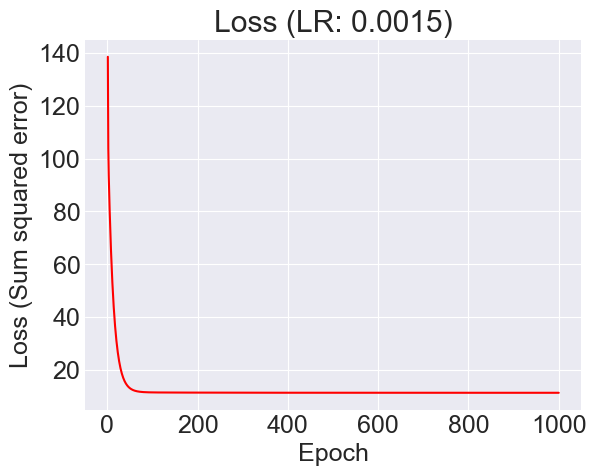

In [39]:
# YOUR CODE HERE
def loss_graph(net, loss_list, plotMarkers=False, title='ADALINE', lr = 0.001):
    '''Helper plotting function provided for you.'''
    n_epochs = len(loss_list)

    x = np.arange(1, n_epochs+1)

    curveStr = '-r'
    if plotMarkers:
        curveStr += 'o'

    plt.plot(x, loss_list, curveStr)
    plt.xlabel('Epoch')
    plt.ylabel('Loss (Sum squared error)')
    plt.title(f'Loss (LR: {lr})')

    plt.show()

net = Adaline()
learnRate = 0.0015
loss, acc = net.fit(X_norm, y, lr = learnRate)
loss_graph(net, loss, lr = learnRate)

**Question 5:** What happens to the loss if the learning rate is increased by several orders of magnitude? Why? **Make 1+ plots that clearly support what you notice.**

**Answer 5:**

Wehen the learning rate is too large, the model overshoots the minimum instead of converging. This makes the loss unstable and eventually explode to huge values. 

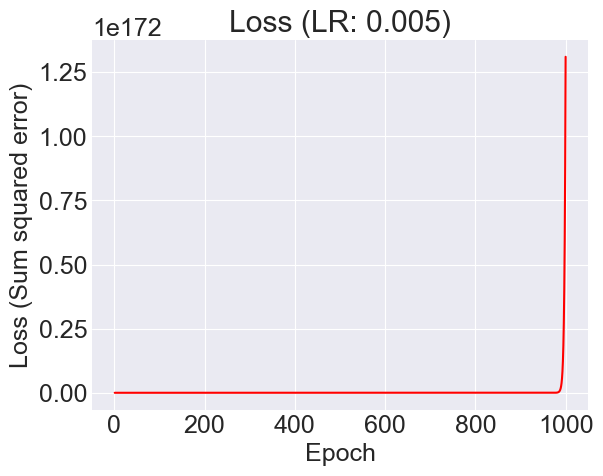

In [40]:
# YOUR CODE HERE
net = Adaline()
learnRate = 0.005
loss, acc = net.fit(X_norm, y, lr = learnRate)
loss_graph (net, loss, lr = learnRate)

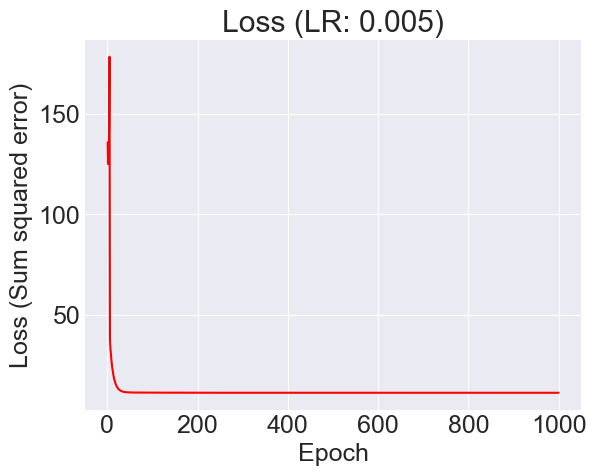

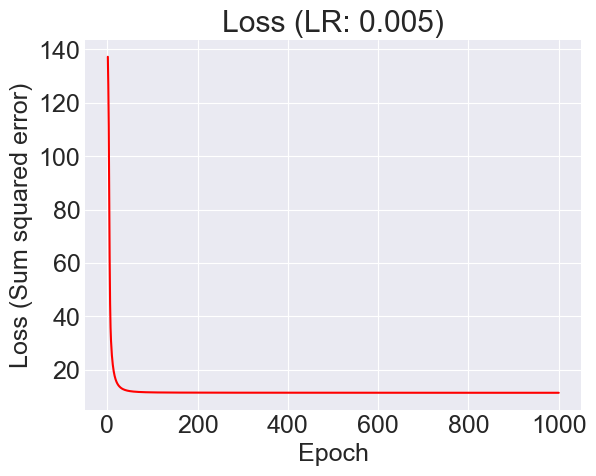

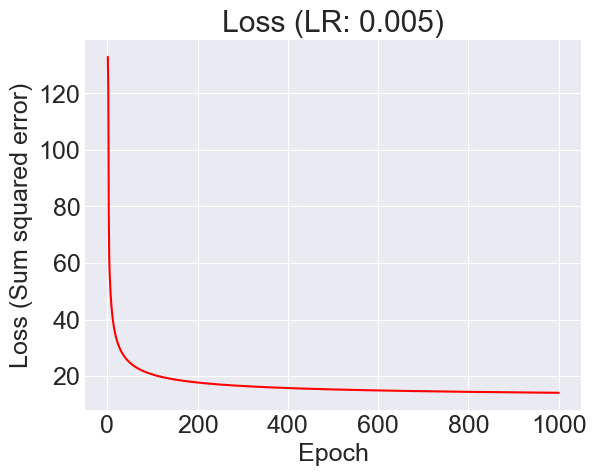

In [51]:
#Extensions:

#1. Counting consecutive losses and decreasing learning rate after 2 consecutive losses
net = Adaline()
learnRate = 0.005
loss, acc = net.fit_count_loss(X_norm, y, lr = learnRate)
loss_graph (net, loss, lr = learnRate)

#2 Having a 'logarithmic' decay learning rate decay
net = Adaline()
learnRate = 0.005
loss_log_decay, acc = net.fit_log_decay(X_norm, y, lr_initial = learnRate, decay_rate = 0.1)
loss_graph (net, loss_log_decay, lr = learnRate)

#3 Having a 'logarithmic' decay learning rate decay with a different decay rate
net = Adaline()
learnRate = 0.005
loss_log_decay, acc = net.fit_log_decay(X_norm, y, lr_initial = learnRate, decay_rate = 0.5)
loss_graph (net, loss_log_decay, lr = learnRate)







### 2d. Visualize class boundaries

For this subtask, you will plot the boundary between points (`eruptions`, `waiting` feature pairs) that get classified as severe (+1) or not (-1). To get there, fill in the blanks and answer the questions below.

In [18]:
# Print your learned wts and bias here after training net on standardized samples

X_stndrd = (X - X.mean(axis=0)) / X.std(axis=0)

net = Adaline()
net.fit(X_stndrd, y)
print(f"Weights: {net.get_wts()}\nBiases: {net.get_bias()}")

Weights: [0.704 0.229]
Biases: 0.2794117647058819


#### Questions

**Question 6.** What is the meaning of each of the above learned weights with respect to the variables/features in the dataset?

*Hint:* Look at your `net_in` equation, look at the features that you feed into the model, look at the scatterplot you made in 1b, think about what features are present in a single training sample.

**Question 7.** Which feature / weight index corresponds to the "y axis value" in your scatterplot from 1b?

**Answer 6:** 

0.704 is the weight for the eruptions feature, since when we select our features, eruptions is the first feature and the waiting time is the second feature. This means the waiting time weight is 0.229. Since both of these weights are positive, it means that both longer eruptions and longer waiting times have a higher likelihood of being classified as severe.

**Answer 7:**

In our scatterplot in 1b, the y-axis corresponds to the waiting time. This means that as you go up on the y-axis, the waiting time increases and severity also increases. This is consistent with our model's weights, which indicate that both features contribute positively to the likelihood of a severe eruption. 

#### Transform weights for plotting

The class boundary equation is $0 = w_0 + w_1 \times x_i + w_2 \times y_i$ for sample $i$ in our data ($i$ goes to 272). But to plot it, we need an equation that looks like $y_i = m \times x_i + b$ where $m$ and $b$ are some combinations of our weights.

1. Scale the weights so that the one corresponding to the "y value" is set to 1, then solve for $y$ (*It might be helpful to work this out by hand*). Once you do, adjust the sign/scale of your weights in code so they match up with the equation you wrote out by hand ( of form $y_i = m \times x_i + b$). **Be careful about the order in which you manipulate the bias and weight values when setting up your equation.**
2. Once you're done, have the cell below print your transformed weights/bias.

In [19]:
# YOUR CODE HERE
#w0 = 0.704 , w1 = 0.229, bias = 0.279
#0 = .279 + 0.701 * eruptions + 0.229 * waiting
#0.229 * waiting = -0.279 - 0.701 * eruptions
#waiting = (-0.279 - 0.701 * eruptions) / 0.229
#waiting = -1.218 - 3.061 * eruptions
bias = 0.279
eruptions_wt = 0.701
waiting_wt = 0.229
m = -eruptions_wt / waiting_wt
b = -bias / waiting_wt
print(f"Transformed equation: waiting = {m:.3f} * eruptions + {b:.3f}")
print(f"Original equation: 0 = {bias:.3f} + {eruptions_wt:.3f} * eruptions + {waiting_wt:.3f} * waiting")
print(f"Slope: {m:.3f}, Intercept: {b:.3f}")


Transformed equation: waiting = -3.061 * eruptions + -1.218
Original equation: 0 = 0.279 + 0.701 * eruptions + 0.229 * waiting
Slope: -3.061, Intercept: -1.218


In the cell below, sample 50 equally spaced x values from -1.5 to 1.5 for plotting the class boundary. Given the `x_i` values, generate `y_i` values using the equation $y_i = m \times x_i + b$ (using your transformed weights from above). 

**Executing the code below should produce a graph that clearly shows this class boundary superimposed on your data scatter plot.**

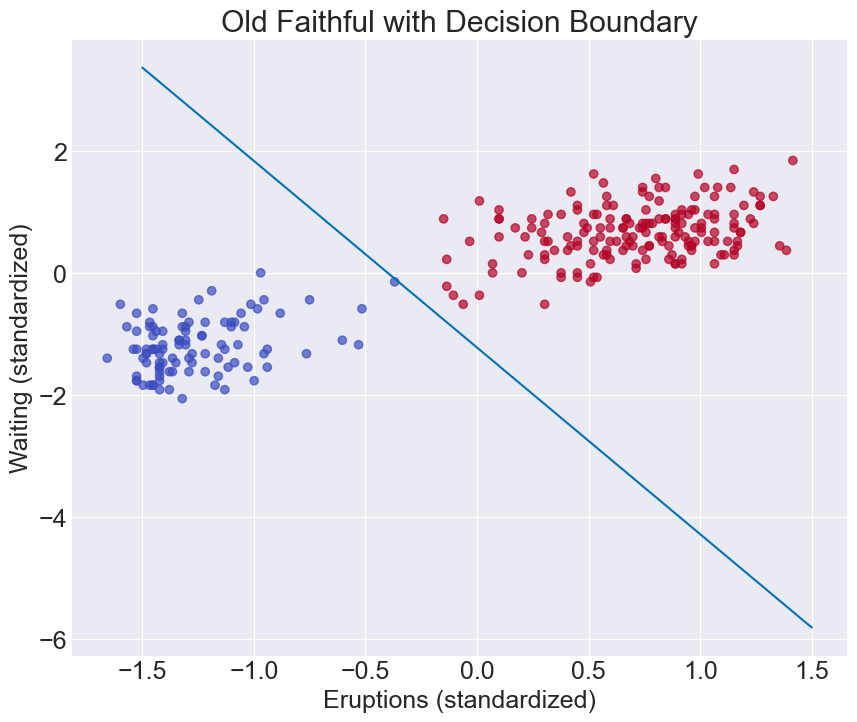

In [26]:
# YOUR CODE HERE
x_equal_space = np.linspace(-1.5, 1.5, 50)
y_equal_space = m * x_equal_space + b

plt.figure(figsize=(10, 8))
plt.scatter(X_stndrd[:, 0], X_stndrd[:, 1], c=y, cmap='coolwarm', alpha=0.7)
plt.plot(x_equal_space, y_equal_space)
plt.xlabel("Eruptions (standardized)")
plt.ylabel("Waiting (standardized)")
plt.title("Old Faithful with Decision Boundary")
plt.show()

## Task 3: Perceptron: A neural network with a different activation function

In this task, you will apply ADALINE to a larger dataset ([Ionosphere dataset](https://archive.ics.uci.edu/dataset/52/ionosphere)) and compare the performance of ADALINE with another binary classification neural network . A **Perceptron** is a single-layer neural network that works exactly the same as ADALINE, except it uses a different network activation function (`netAct`). The activation function computes the `netAct` as follows:

$$\text{netAct}_i = f(\text{netIn}_i) = 1  \text{ if netIn}_i \geq 0$$
$$\text{netAct}_i = f(\text{netIn}_i) = -1 \text{ if netIn}_i < 0$$

### 3a. Implement and test a Perceptron

1. Create a new class in `adaline.py` that will represent your Perceptron classifier. It should inherit from `Adaline`. Override/write any necessary functions. **Hint:** This should be really quick, short, and simple.
2. In the cell below, train your Perceptron on the same standardized Old Faithful data by making loss and accuracy plots like you have been using in previous tasks (*though you should replace the default title in `plot_adaline_train` with Perceptron*).

If everything is working, you should get very similar results with your Perceptron as above with ADALINE.

In [4]:
from adaline import Perceptron

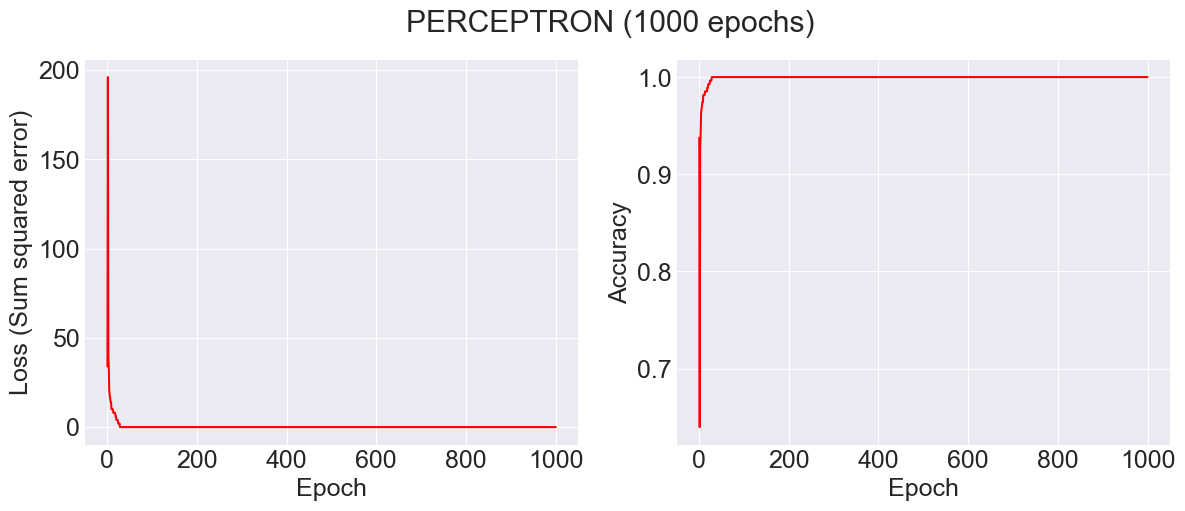

In [19]:
# YOUR CODE HERE
df = pd.read_csv('old_faithful.csv')
X = df[['eruptions','waiting']].to_numpy()
y = df['severe'].to_numpy()

X_stndrd = (X - X.mean(axis=0)) / X.std(axis=0)

net = Perceptron()
loss, acc = net.fit(X_stndrd, y)

plot_adaline_train(net, loss, acc, title = 'PERCEPTRON')

### 3b. Compare performance between ADALINE and Perceptron on Ionosphere dataset

Your goal is to train, compare, and analyze the performance of your ADALINE and Perceptron networks on the Ionosphere dataset.

The [Ionosphere dataset](https://archive.ics.uci.edu/dataset/52/ionosphere) is radar signal data collected in Goose Bay, Labrador. It is a more complex dataset than old faithful, with 33 features (but still 2 classes). The class values are coded 'g' for good radar signal and 'b' for bad radar signal.

**Please download the CSV file from the CS343 project website (not above UCI link)** — I have slightly modified the dataset for your convenience.

**TODO:**
1. Load in and normalize the Ionosphere dataset by standardization. Note that there are no headers in the CSV file and the class values are specified in the last column — **make sure that they are coded properly** (i.e. $-1$ and $+1$).
2. In the cell below, use the provided `plot_nets_train` helper function to create a 1x2 plot showing training loss and accuracy of the two networks.

Your goal is to play with the hyperparameters until both networks **start** plateauing in accuracy. Your accuracy doesn't literally need to stop increasing — you just want the visual impression of it doing so. Don't train the networks too long so that you miss the early trend in loss and/or accuracy.

In [20]:
def plot_nets_train(loss_lists, acc_lists, net_names, plotMarkers=False):
    '''Creates a 1x2 grid of plots showing loss over epochs (left column) and
    accuracy over epochs (right column) for one or more network (num_nets in total).
    Generalizes `plot_adaline_train` for multiple trained networks.

    For example, in the case of two networks (e.g. adaline and perceptron; num_nets=2),
    there would be two curves in each of the two plots.

    Put differently, the following function call would produce the same pair of plots you've
    been getting up until this point with a single adaline network:
        plot_adaline_train(loss_lists[0], acc_lists[0])

    Parameters:
    -----------
    loss_lists: Python lists of ndarrays. len(loss_lists) = num_nets. len(loss_lists[0]) = n_epochs.
        This would be a list of the loss histories for each of the nets being plotted.
    acc_lists: Python lists of ndarrays. len(acc_lists) = num_nets. len(acc_lists[0]) = n_epochs.
        This would be a list of the accuracy histories for each of the nets being plotted.
    net_names: Python list of str. len(net_names) = num_nets.
        Identifying names of each net (e.g. for legend).
    plotMarkers: boolean.
        Should we draw a plot marker at each epoch on each curve?
    '''
    n_nets = len(net_names)
    n_epochs = len(loss_lists[0])

    colors = ['orange', 'blue', 'red']

    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
    fig.suptitle(f'{n_nets} networks trained for ({n_epochs} epochs)')

    for loss_list, acc_list, color in zip(loss_lists, acc_lists, colors):
        x = np.arange(1, n_epochs+1)

        curveStr = '-'
        if plotMarkers:
            curveStr += 'o'

        ax1.plot(x, loss_list, curveStr, c=color)
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss (Sum squared error)')
        ax2.plot(x, acc_list, curveStr, c=color)
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Accuracy')

    plt.legend(net_names)
    plt.show()

Adaline Loss: 74.23004578678206 
Adaline Accuracy: 0.9002849002849003
Perceptron Loss: 58.0 
Perceptron Accuracy: 0.9173789173789174


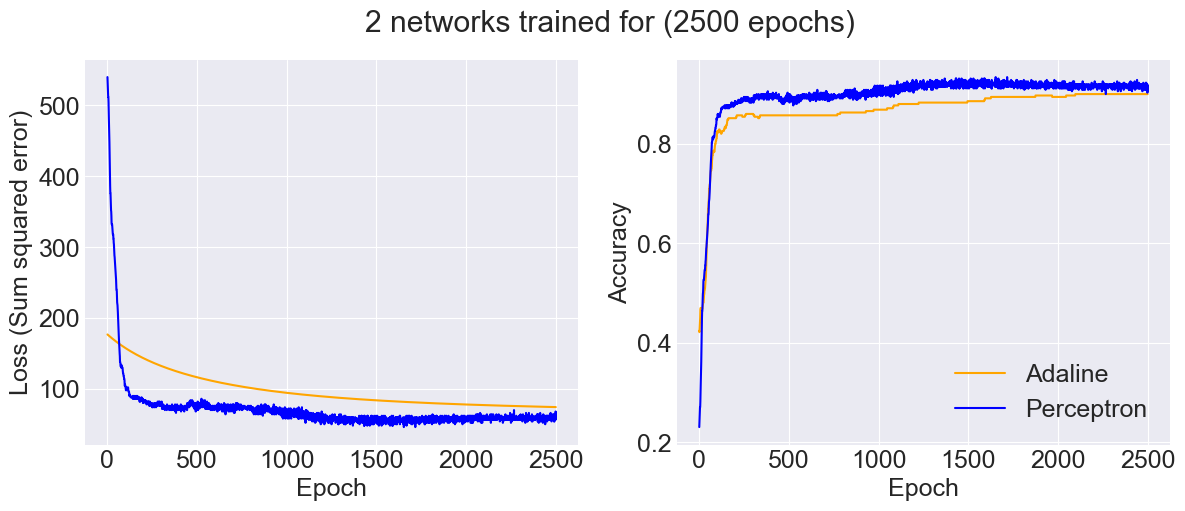

In [35]:
# YOUR CODE HERE
df = pd.read_csv('ionosphere.csv', header=None)
X = df.iloc[:, :-1].to_numpy()
y = np.where(df.iloc[:, -1] == 'g', 1, -1)

X_stndrd = (X - X.mean(axis=0)) / X.std(axis=0)

ada = Adaline()
per = Perceptron()

# Moderate increases for both networks
loss_ada, acc_ada = ada.fit(X_stndrd, y, n_epochs=2500, lr=0.000001)
loss_per, acc_per = per.fit(X_stndrd, y, n_epochs=2500, lr=0.000001)

print(f"Adaline Loss: {loss_ada[-1]} \nAdaline Accuracy: {acc_ada[-1]}")
print(f"Perceptron Loss: {loss_per[-1]} \nPerceptron Accuracy: {acc_per[-1]}")

plot_nets_train((loss_ada, loss_per),(acc_ada, acc_per),("Adaline", "Perceptron"))



#### Questions

**Question 8.** What accuracy are you able to achieve on the Ionosphere dataset with each networks at the end of training?

**Answer 8:** 

I was able to achieve ~90% accuracy with ADALINE and ~92% accuracy with Perceptron. 

### 3c. Influence of learning rate

Now let's analyze the effect learning rate on the nets. Make plots that illustrate the effect of the following on ADALINE and Perceptron learning.

1. learning rate increased by 1+ order of magnitude in each network.
2. learning rate decreased by 1+ order of magnitude in each network. *You will likely need to increase the number of training epochs too.*

#### Questions

**Question 9:** Interpret the difference in behavior between the two nets.

Adaline Loss: 99.70842328675474 
Adaline Accuracy: 0.8575498575498576
Perceptron Loss: 56.0 
Perceptron Accuracy: 0.9202279202279202


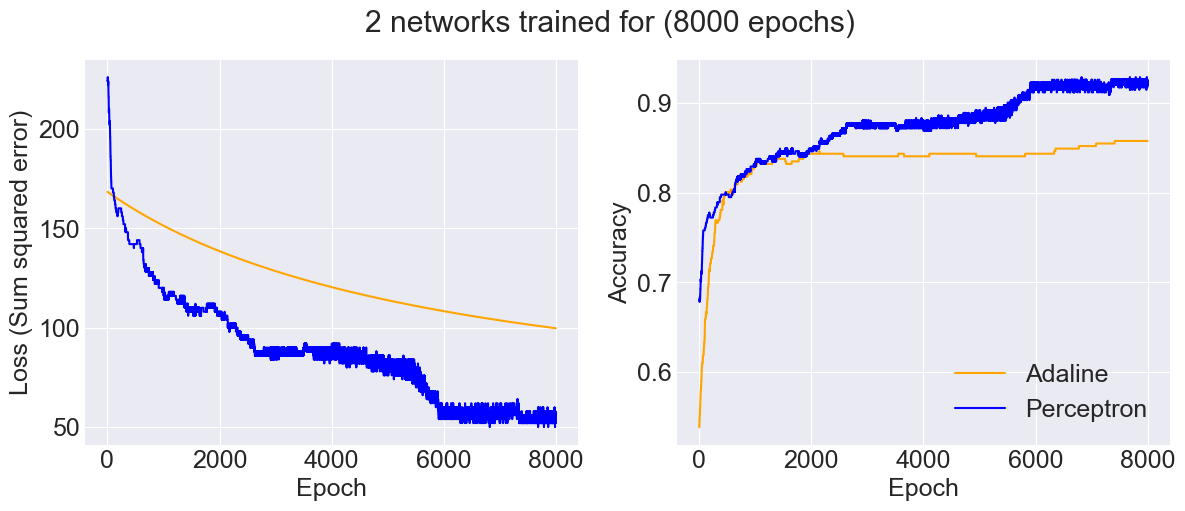

In [58]:
loss_ada, acc_ada = ada.fit(X_stndrd, y, n_epochs=8000, lr=0.0000001)
loss_per, acc_per = per.fit(X_stndrd, y, n_epochs=8000, lr=0.0000001)


print(f"Adaline Loss: {loss_ada[-1]} \nAdaline Accuracy: {acc_ada[-1]}")
print(f"Perceptron Loss: {loss_per[-1]} \nPerceptron Accuracy: {acc_per[-1]}")

plot_nets_train((loss_ada, loss_per),(acc_ada, acc_per),("Adaline", "Perceptron"))


Adaline Loss: 64.3003800966787 
Adaline Accuracy: 0.9031339031339032
Perceptron Loss: 60.0 
Perceptron Accuracy: 0.9145299145299145


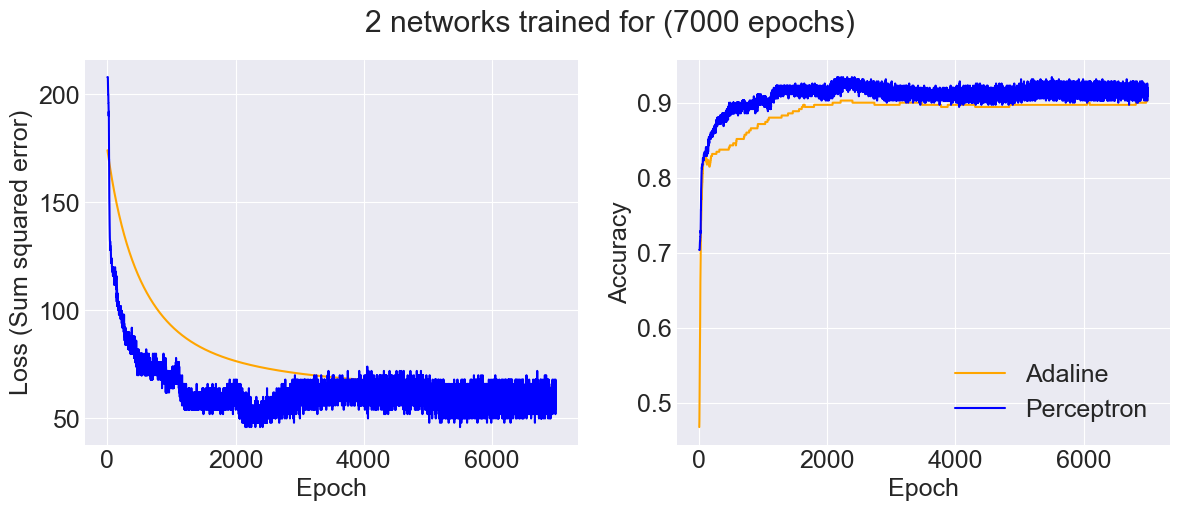

In [56]:
# YOUR CODE HEREloss_ada, acc_ada = ada.fit(X_stndrd, y, n_epochs=8000, lr=0.00001)
loss_ada, acc_ada = ada.fit(X_stndrd, y, n_epochs=7000, lr=0.000001)
loss_per, acc_per = per.fit(X_stndrd, y, n_epochs=7000, lr=0.000001)


print(f"Adaline Loss: {loss_ada[-1]} \nAdaline Accuracy: {acc_ada[-1]}")
print(f"Perceptron Loss: {loss_per[-1]} \nPerceptron Accuracy: {acc_per[-1]}")

plot_nets_train((loss_ada, loss_per),(acc_ada, acc_per),("Adaline", "Perceptron"))


**Answer 9:**

Increasing the learning rate by 1 order of magnitude dropped my accurancy for adaline to ~85 and kept my accuracy for perceptron roughly the same. On the other hand, decreasing it by a order of magnitude kept both about the same. This might be because our learning rate was very large to start. 

### 3d. Plotting classifications

Make two scatter plots (one per network) showing the feature at index 4 on x-axis and the feature at index 19 on the y-axis. Samples should be color coded one of two colors: whether the class was correctly or incorrectly predicted.


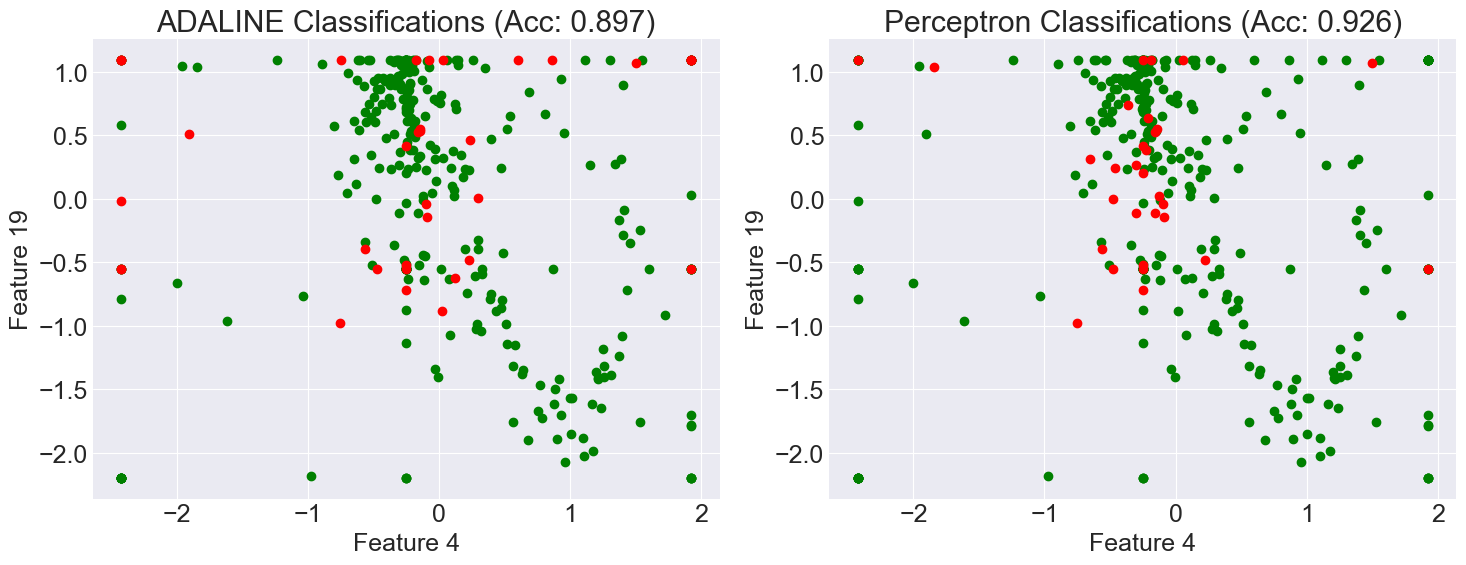

In [66]:
# YOUR CODE HERE
loss_ada, acc_ada = ada.fit(X_stndrd, y, n_epochs=7000, lr=0.000001)
loss_per, acc_per = per.fit(X_stndrd, y, n_epochs=7000, lr=0.000001)

y_pred_ada = ada.predict(X_stndrd)
y_pred_per = per.predict(X_stndrd)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

correct_ada = (y == y_pred_ada)
ax1.scatter(X_stndrd[correct_ada, 4], X_stndrd[correct_ada, 19], 
           c='green')
ax1.scatter(X_stndrd[~correct_ada, 4], X_stndrd[~correct_ada, 19], 
           c='red')
ax1.set_xlabel('Feature 4')
ax1.set_ylabel('Feature 19')
ax1.set_title(f'ADALINE Classifications (Acc: {acc_ada[-1]:.3f})')


# Perceptron plot
correct_per = (y == y_pred_per)
ax2.scatter(X_stndrd[correct_per, 4], X_stndrd[correct_per, 19], 
           c='green')
ax2.scatter(X_stndrd[~correct_per, 4], X_stndrd[~correct_per, 19], 
           c='red',)
ax2.set_xlabel('Feature 4')
ax2.set_ylabel('Feature 19')
ax2.set_title(f'Perceptron Classifications (Acc: {acc_per[-1]:.3f})')


plt.tight_layout()
plt.show()


#### Questions

**Question 10:** In your scatter plots showing correct and incorrect sample classifications, how is it possible that misclassifications are so dispersed and do not appear to either side of a simple boundary?

**Answer 10:** 

Because the networks are using all of the featues to classify the points, not just features 4 and 19. Additionally, we are looking at a 2-dimensional view, but the actual data is 33-dimensional. So, the points may look 'close together' on these views, but actually be very far apart from another 'angle'.